Iris Dataset Shape: (150, 4)

DATASET: Iris

------------------------------------------------------------
GAUSSIAN KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.975
Testing Accuracy  : 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Bias-Variance Analysis (Gaussian SVM)
Model is BALANCED

------------------------------------------------------------
RBF KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.975
Testing Accuracy  : 0.9667

Classification Report:
            

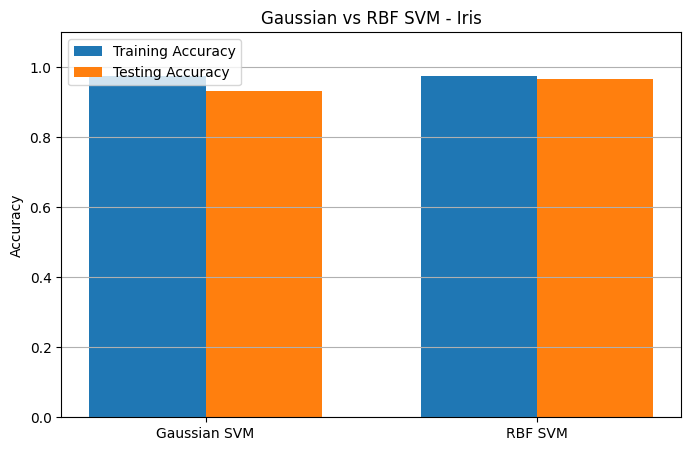


Breast Cancer Dataset Shape: (569, 30)

DATASET: Breast Cancer

------------------------------------------------------------
GAUSSIAN KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 1.0
Testing Accuracy  : 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.60      0.72        42
           1       0.80      0.97      0.88        72

    accuracy                           0.83       114
   macro avg       0.87      0.78      0.80       114
weighted avg       0.85      0.83      0.82       114

Confusion Matrix:
[[25 17]
 [ 2 70]]

Bias-Variance Analysis (Gaussian SVM)
HIGH VARIANCE -> OVERFITTING

------------------------------------------------------------
RBF KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.9824
Testing Accuracy  : 0.9825

Classification Report:
              precision    recall  f1-score   support


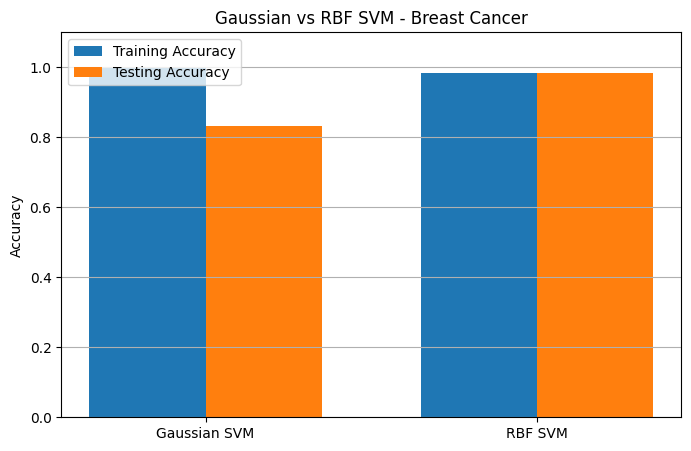


Two Moons Dataset Shape: (500, 2)

DATASET: Two Moons

------------------------------------------------------------
GAUSSIAN KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.9675
Testing Accuracy  : 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.98      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Confusion Matrix:
[[50  0]
 [ 1 49]]

Bias-Variance Analysis (Gaussian SVM)
Model is BALANCED

------------------------------------------------------------
RBF KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.9675
Testing Accuracy  : 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0

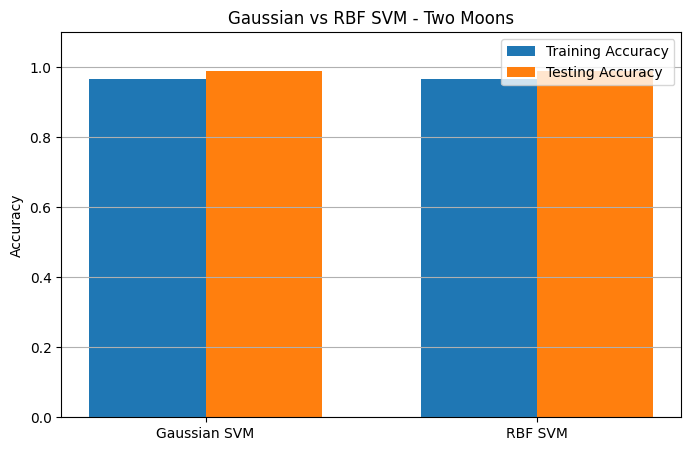

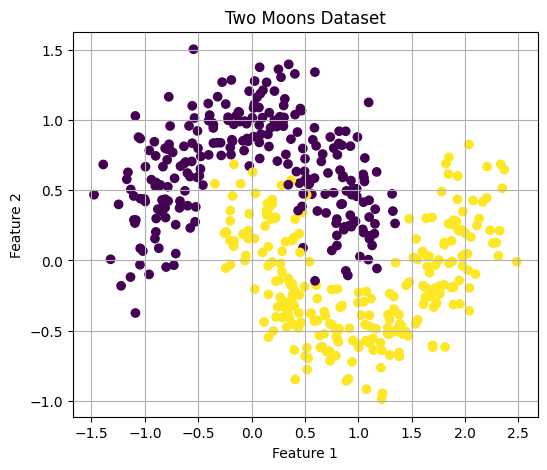


Circles Dataset Shape: (500, 2)

DATASET: Circles

------------------------------------------------------------
GAUSSIAN KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.9925
Testing Accuracy  : 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.98      0.98      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

Confusion Matrix:
[[49  1]
 [ 1 49]]

Bias-Variance Analysis (Gaussian SVM)
Model is BALANCED

------------------------------------------------------------
RBF KERNEL SVM RESULTS
------------------------------------------------------------
Training Accuracy : 0.9925
Testing Accuracy  : 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.98 

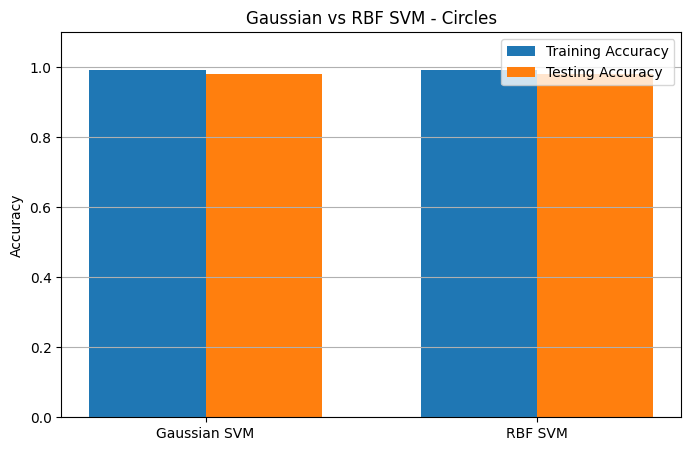

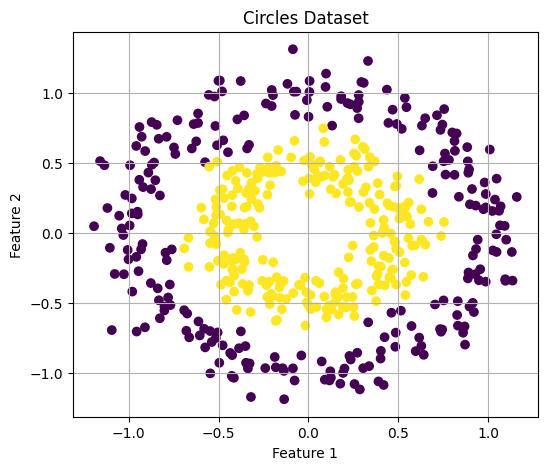

In [1]:
# Programming Assignment 37
# Gaussian and RBF Kernel Support Vector Machine
# Datasets:
# 1. Iris
# 2. Breast Cancer
# 3. Two Moons
# 4. Circles

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------------
# Function to evaluate Gaussian and RBF SVM
# --------------------------------------------------
def run_svm_models(X, y, dataset_name):
    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print("=" * 80)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Standardization
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --------------------------------------------------
    # Gaussian SVM
    # --------------------------------------------------
    gaussian_svm = SVC(kernel='rbf', gamma=0.5, C=1.0, random_state=42)
    gaussian_svm.fit(X_train_scaled, y_train)

    y_train_pred_g = gaussian_svm.predict(X_train_scaled)
    y_test_pred_g = gaussian_svm.predict(X_test_scaled)

    train_acc_g = accuracy_score(y_train, y_train_pred_g)
    test_acc_g = accuracy_score(y_test, y_test_pred_g)

    print("\n" + "-" * 60)
    print("GAUSSIAN KERNEL SVM RESULTS")
    print("-" * 60)
    print("Training Accuracy :", round(train_acc_g, 4))
    print("Testing Accuracy  :", round(test_acc_g, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred_g))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred_g))

    # Bias-Variance check
    print("\nBias-Variance Analysis (Gaussian SVM)")
    if train_acc_g < 0.80 and test_acc_g < 0.80:
        print("HIGH BIAS -> UNDERFITTING")
    elif (train_acc_g - test_acc_g) > 0.10:
        print("HIGH VARIANCE -> OVERFITTING")
    else:
        print("Model is BALANCED")

    # --------------------------------------------------
    # RBF SVM
    # --------------------------------------------------
    rbf_svm = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
    rbf_svm.fit(X_train_scaled, y_train)

    y_train_pred_r = rbf_svm.predict(X_train_scaled)
    y_test_pred_r = rbf_svm.predict(X_test_scaled)

    train_acc_r = accuracy_score(y_train, y_train_pred_r)
    test_acc_r = accuracy_score(y_test, y_test_pred_r)

    print("\n" + "-" * 60)
    print("RBF KERNEL SVM RESULTS")
    print("-" * 60)
    print("Training Accuracy :", round(train_acc_r, 4))
    print("Testing Accuracy  :", round(test_acc_r, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred_r))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred_r))

    # Bias-Variance check
    print("\nBias-Variance Analysis (RBF SVM)")
    if train_acc_r < 0.80 and test_acc_r < 0.80:
        print("HIGH BIAS -> UNDERFITTING")
    elif (train_acc_r - test_acc_r) > 0.10:
        print("HIGH VARIANCE -> OVERFITTING")
    else:
        print("Model is BALANCED")

    # --------------------------------------------------
    # Comparison Table
    # --------------------------------------------------
    comparison_df = pd.DataFrame({
        "Model": ["Gaussian SVM", "RBF SVM"],
        "Training Accuracy": [train_acc_g, train_acc_r],
        "Testing Accuracy": [test_acc_g, test_acc_r],
        "Difference": [abs(train_acc_g - test_acc_g), abs(train_acc_r - test_acc_r)]
    })

    print("\nModel Comparison:")
    print(comparison_df)

    # Bar chart
    models = ["Gaussian SVM", "RBF SVM"]
    train_scores = [train_acc_g, train_acc_r]
    test_scores = [test_acc_g, test_acc_r]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, train_scores, width, label='Training Accuracy')
    plt.bar(x + width/2, test_scores, width, label='Testing Accuracy')
    plt.xticks(x, models)
    plt.ylim(0, 1.1)
    plt.ylabel("Accuracy")
    plt.title(f"Gaussian vs RBF SVM - {dataset_name}")
    plt.legend()
    plt.grid(axis='y')
    plt.show()


# --------------------------------------------------
# 1. Iris Dataset
# --------------------------------------------------
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name="Target")

print("Iris Dataset Shape:", X_iris.shape)
run_svm_models(X_iris, y_iris, "Iris")

# --------------------------------------------------
# 2. Breast Cancer Dataset
# --------------------------------------------------
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = pd.Series(cancer.target, name="Target")

print("\nBreast Cancer Dataset Shape:", X_cancer.shape)
run_svm_models(X_cancer, y_cancer, "Breast Cancer")

# --------------------------------------------------
# 3. Two Moons Dataset
# --------------------------------------------------
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=42)
X_moons = pd.DataFrame(X_moons, columns=["Feature 1", "Feature 2"])
y_moons = pd.Series(y_moons, name="Target")

print("\nTwo Moons Dataset Shape:", X_moons.shape)
run_svm_models(X_moons, y_moons, "Two Moons")

# Scatter plot for Two Moons
plt.figure(figsize=(6, 5))
plt.scatter(X_moons.iloc[:, 0], X_moons.iloc[:, 1], c=y_moons)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# --------------------------------------------------
# 4. Circles Dataset
# --------------------------------------------------
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X_circles = pd.DataFrame(X_circles, columns=["Feature 1", "Feature 2"])
y_circles = pd.Series(y_circles, name="Target")

print("\nCircles Dataset Shape:", X_circles.shape)
run_svm_models(X_circles, y_circles, "Circles")

# Scatter plot for Circles
plt.figure(figsize=(6, 5))
plt.scatter(X_circles.iloc[:, 0], X_circles.iloc[:, 1], c=y_circles)
plt.title("Circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()